## Step 1: Load and Inspect Data

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/KaggleV2-May-2016.csv")

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## Step 2: Convert Dates Properly

In [ ]:
# Standardize column names
df.columns = df.columns.str.lower()

# Convert dates
df["appointmentday"] = pd.to_datetime(df["appointmentday"]).dt.tz_localize(None)
df["scheduledday"] = pd.to_datetime(df["scheduledday"]).dt.tz_localize(None)
# Rename column
df.rename(columns={"no-show": "no_show"}, inplace=True)

df.head()

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08,2016-04-29,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27,2016-04-29,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04,2016-04-29,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31,2016-04-29,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23,2016-04-29,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## Step 3: Filter Only Attended Visits

In [3]:
df = df[df["no_show"] == "No"].copy()

In [4]:
df.shape

(88208, 14)

In [5]:
# Time span of data
df["appointmentday"].min(), df["appointmentday"].max()

(Timestamp('2016-04-29 00:00:00'), Timestamp('2016-06-08 00:00:00'))

## Step 4: Aggregate to Daily Patient Volume

In [6]:
daily_visits = (df.groupby("appointmentday").size().rename("patient_count").reset_index())

## Step 5: Sort and Index Data

In [7]:
daily_visits = daily_visits.sort_values("appointmentday")

daily_visits.set_index("appointmentday", inplace=True)

## Step 6: Handle Missing Dates
Time-series models require continuous time index.

In [8]:
daily_visits = daily_visits.asfreq("D")

In [9]:
# Now fill missing days:
daily_visits["patient_count"] = daily_visits["patient_count"].fillna(0)

## Step 7: Validate Time Series

In [10]:
daily_visits.head()

,patient_count
appointmentday,
2016-04-29,2602.0
2016-04-30,0.0
2016-05-01,0.0
2016-05-02,3515.0
2016-05-03,3425.0


In [11]:
daily_visits.tail()

,patient_count
appointmentday,
2016-06-04,0.0
2016-06-05,0.0
2016-06-06,3819.0
2016-06-07,3600.0
2016-06-08,3705.0


In [12]:
daily_visits.isnull().sum()

patient_count    0
dtype: int64

## Step 8: Plot the Time Series

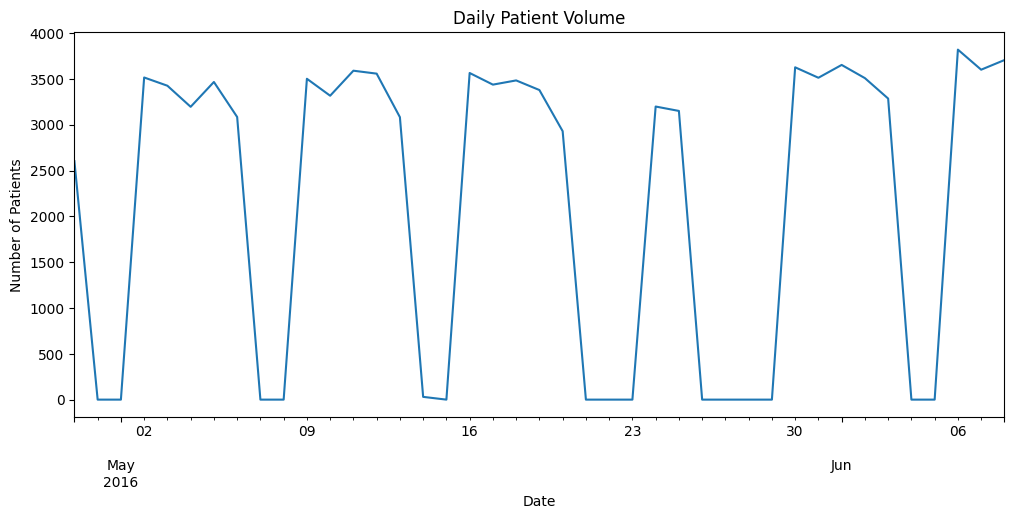

In [13]:
import matplotlib.pyplot as plt

daily_visits["patient_count"].plot(figsize=(12,5))
plt.title("Daily Patient Volume")
plt.xlabel("Date")
plt.ylabel("Number of Patients")
plt.show()

In [14]:
plt.savefig("../outputs/figures/daily_patient_volume.png")

<Figure size 640x480 with 0 Axes>

## Step 9: Check for Patterns

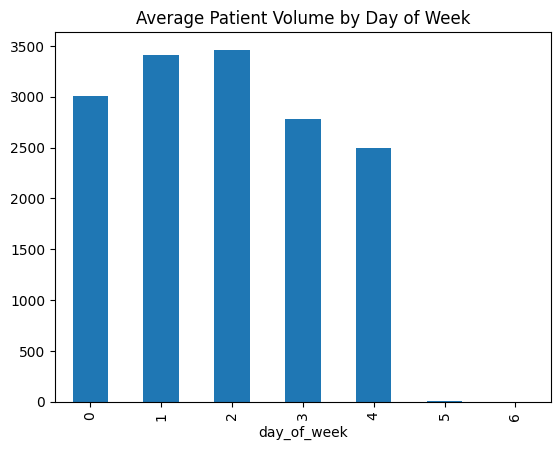

In [15]:
daily_visits["day_of_week"] = daily_visits.index.dayofweek

daily_visits.groupby("day_of_week")["patient_count"].mean().plot(kind="bar")
plt.title("Average Patient Volume by Day of Week")
plt.show()

In [16]:
plt.savefig("../outputs/figures/dayofweek_patient_volume_pattern.png")

<Figure size 640x480 with 0 Axes>

In [17]:
# Save processed data
daily_visits.to_csv("../data/processed/daily_patient_volume.csv")